# Rastros del 36 · Fase 2
## Integración nacional de datos sobre represión franquista
**Autora:** [Tu nombre]  
**Proyecto:** Big Data aplicado a la Memoria Histórica de España

---

En esta segunda fase ampliamos el análisis incorporando nuevas fuentes
y territorios. El objetivo es construir un **dataset unificado nacional**
que permita comparar patrones de represión entre comunidades autónomas.

### Fuentes incorporadas en esta fase
- **Fase 1:** Víctimas mortales de la Guerra Civil en Euskadi (Open Data Euskadi) — 21.367 registros nominales
- **Fase 2:** Fosas comunes de la Guerra Civil en Andalucía (Junta de Andalucía) — 615 fosas documentadas

### Objetivo
Unificar, comparar y visualizar conjuntamente ambos datasets,
sentando las bases del modelo de datos nacional.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [3]:
# Dataset Fase 1 — Víctimas individuales Euskadi
df_euskadi = pd.read_excel('victimas_guerra_civil.xlsx')
df_euskadi['fuente'] = 'Open Data Euskadi'
df_euskadi['comunidad'] = 'País Vasco'
df_euskadi['tipo_registro'] = 'victima_individual'

# Dataset Fase 2 — Fosas Andalucía
df_andalucia = pd.read_csv('mapa_fosas_victimas_guerra_civil_andalucia.csv', 
                            sep=None, engine='python', encoding='utf-8')
df_andalucia['fuente'] = 'Junta de Andalucía'
df_andalucia['comunidad'] = 'Andalucía'
df_andalucia['tipo_registro'] = 'fosa'

print(f"✅ Euskadi:   {len(df_euskadi):>6,} registros | {df_euskadi.shape[1]} columnas")
print(f"✅ Andalucía: {len(df_andalucia):>6,} registros | {df_andalucia.shape[1]} columnas")
print(f"\n--- COLUMNAS ANDALUCÍA ---")
for i, col in enumerate(df_andalucia.columns, 1):
    print(f"{i:02d}. {col}")

✅ Euskadi:   21,367 registros | 25 columnas
✅ Andalucía:    615 registros | 19 columnas

--- COLUMNAS ANDALUCÍA ---
01. Unnamed: 0
02. Titulo
03. Caracter
04. Provincia
05. Municipio
06. Fecha
07. Titularidad
08. Fotografia_AreaMunicipio
09. Fotografia_PieFosa
10. LocalizacionDescripion
11. Victimas
12. RelatoHistorico
13. Fecha_Actuacion
14. Promotor_Actuacion
15. Descripcion_Actuacion
16. URL
17. fuente
18. comunidad
19. tipo_registro


In [4]:
# Eliminamos columna índice innecesaria
df_andalucia = df_andalucia.drop(columns=['Unnamed: 0'])

# Exploramos la columna Victimas — cuántas fosas tienen dato
print(f"Fosas con número de víctimas registrado: {df_andalucia['Victimas'].notna().sum()} de {len(df_andalucia)}")
print(f"\n--- MUESTRA DE VALORES EN 'Victimas' ---")
print(df_andalucia['Victimas'].value_counts().head(10))

print(f"\n--- FOSAS POR PROVINCIA ---")
print(df_andalucia['Provincia'].value_counts())

Fosas con número de víctimas registrado: 615 de 615

--- MUESTRA DE VALORES EN 'Victimas' ---
Victimas
Desconocido    153
1               47
2               26
3               22
6               20
10              20
5               19
14              16
4               15
20              12
Name: count, dtype: int64

--- FOSAS POR PROVINCIA ---
Provincia
Sevilla    130
Huelva     120
Cádiz      100
Granada     87
Málaga      76
Córdoba     69
Jaén        24
Almería      9
Name: count, dtype: int64


### Nota metodológica — Heterogeneidad de fuentes

Los dos datasets tienen naturalezas distintas:

- **Euskadi** registra **víctimas individuales** con datos biográficos completos
- **Andalucía** registra **fosas comunes** con número agregado de víctimas

Esta heterogeneidad es habitual en proyectos de integración de fuentes 
archivísticas: cada institución documenta la realidad desde su propia 
perspectiva y con sus propios criterios.

El reto del proyecto es construir un modelo de datos que respete 
esa diversidad mientras permite el análisis comparativo.

In [5]:
# Convertimos Victimas a numérico
df_andalucia['Victimas_num'] = pd.to_numeric(df_andalucia['Victimas'], errors='coerce')

# Resumen
total_conocidas = df_andalucia['Victimas_num'].sum()
total_fosas = len(df_andalucia)
fosas_sin_dato = df_andalucia['Victimas_num'].isna().sum()

print(f"✅ Total víctimas contabilizadas en Andalucía: {int(total_conocidas):,}")
print(f"⚠️  Fosas sin número de víctimas conocido:     {fosas_sin_dato} ({fosas_sin_dato/total_fosas*100:.1f}%)")
print(f"\n--- VÍCTIMAS POR PROVINCIA ---")
prov_victimas = df_andalucia.groupby('Provincia')['Victimas_num'].agg(['sum','count','mean']).round(1)
prov_victimas.columns = ['Total víctimas', 'Nº fosas', 'Media víctimas/fosa']
prov_victimas = prov_victimas.sort_values('Total víctimas', ascending=False)
print(prov_victimas.to_string())

✅ Total víctimas contabilizadas en Andalucía: 46,829
⚠️  Fosas sin número de víctimas conocido:     157 (25.5%)

--- VÍCTIMAS POR PROVINCIA ---
           Total víctimas  Nº fosas  Media víctimas/fosa
Provincia                                               
Granada           10879.0        65                167.4
Huelva            10399.0        86                120.9
Sevilla            8850.0        81                109.3
Málaga             7662.0        69                111.0
Córdoba            5395.0        68                 79.3
Jaén               2009.0        24                 83.7
Cádiz              1275.0        57                 22.4
Almería             360.0         8                 45.0


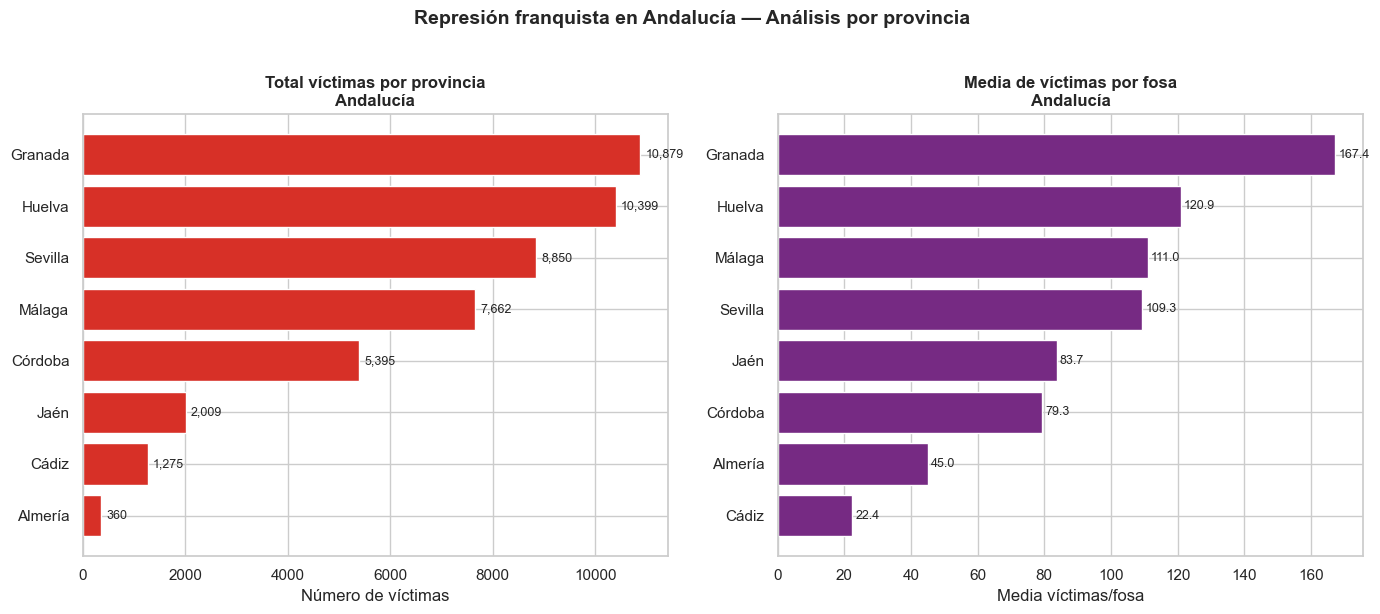

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1 — Total víctimas por provincia
prov_plot = prov_victimas.sort_values('Total víctimas')
axes[0].barh(prov_plot.index, prov_plot['Total víctimas'], color='#d73027')
axes[0].set_title('Total víctimas por provincia\nAndalucía', fontweight='bold')
axes[0].set_xlabel('Número de víctimas')
for i, (idx, row) in enumerate(prov_plot.iterrows()):
    axes[0].text(row['Total víctimas'] + 100, i, f"{int(row['Total víctimas']):,}", va='center', fontsize=9)

# Gráfico 2 — Media víctimas por fosa
prov_media = prov_victimas.sort_values('Media víctimas/fosa')
axes[1].barh(prov_media.index, prov_media['Media víctimas/fosa'], color='#762a83')
axes[1].set_title('Media de víctimas por fosa\nAndalucía', fontweight='bold')
axes[1].set_xlabel('Media víctimas/fosa')
for i, (idx, row) in enumerate(prov_media.iterrows()):
    axes[1].text(row['Media víctimas/fosa'] + 1, i, f"{row['Media víctimas/fosa']}", va='center', fontsize=9)

plt.suptitle('Represión franquista en Andalucía — Análisis por provincia', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Coordenadas capitales andaluzas
coord_andalucia = {
    'Sevilla':  (37.3891, -5.9845),
    'Huelva':   (37.2614, -6.9447),
    'Cádiz':    (36.5271, -6.2886),
    'Granada':  (37.1773, -3.5986),
    'Málaga':   (36.7213, -4.4213),
    'Córdoba':  (37.8882, -4.7794),
    'Jaén':     (37.7796, -3.7849),
    'Almería':  (36.8340, -2.4637),
}

# Mapa centrado en Andalucía
mapa_and = folium.Map(location=[37.5, -4.5], zoom_start=7,
                      tiles='CartoDB positron')

for _, row in prov_victimas.iterrows():
    if row.name in coord_andalucia:
        lat, lon = coord_andalucia[row.name]
        victimas = int(row['Total víctimas']) if not pd.isna(row['Total víctimas']) else 0
        fosas = int(row['Nº fosas'])
        radio = np.log1p(victimas) * 3

        folium.CircleMarker(
            location=[lat, lon],
            radius=radio,
            color='#d73027',
            fill=True,
            fill_color='#d73027',
            fill_opacity=0.6,
            popup=folium.Popup(
                f"<b>{row.name}</b><br>"
                f"Víctimas: {victimas:,}<br>"
                f"Fosas: {fosas}<br>"
                f"Media: {row['Media víctimas/fosa']} víctimas/fosa",
                max_width=200
            ),
            tooltip=f"{row.name}: {victimas:,} víctimas en {fosas} fosas"
        ).add_to(mapa_and)

titulo = '''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%);
     z-index: 1000; background-color: white; padding: 10px 20px;
     border-radius: 8px; border: 2px solid #d73027;
     font-family: Arial; font-size: 14px; font-weight: bold; text-align: center;">
     🗺️ Rastros del 36 · Fosas comunes en Andalucía<br>
     <span style="font-size:11px; font-weight:normal;">
     Fuente: Junta de Andalucía | Tamaño proporcional al nº de víctimas</span>
</div>'''
mapa_and.get_root().html.add_child(folium.Element(titulo))

mapa_and.save('mapa_fosas_andalucia.html')
print("✅ Mapa guardado como 'mapa_fosas_andalucia.html'")
mapa_and

✅ Mapa guardado como 'mapa_fosas_andalucia.html'


In [11]:
# Coordenadas provincias Euskadi
coord_euskadi = {
    'Bizkaia':      (43.2630, -2.9350),
    'Gipuzkoa':     (43.3128, -1.9754),
    'Araba/Álava':  (42.8469, -2.6727),
    'Asturias':     (43.3614, -5.8593),
    'Cantabria':    (43.1828, -3.9878),
    'Burgos':       (42.3440, -3.6969),
    'Madrid':       (40.4168, -3.7038),
    'Navarra':      (42.6954, -1.6761),
    'Teruel':       (40.3456, -1.1065),
    'Lleida':       (41.6176,  0.6200),
    'Tarragona':    (41.1189,  1.2445),
    'Barcelona':    (41.3851,  2.1734),
    'Zaragoza':     (41.6561, -0.8773),
    'Rioja (La)':   (42.2871, -2.5396),
}

# Agrupamos Euskadi por provincia
euskadi_prov = df_euskadi['Provincia fallecimiento'].value_counts().reset_index()
euskadi_prov.columns = ['Provincia', 'Victimas']
euskadi_prov['comunidad'] = 'País Vasco'
euskadi_prov['tipo'] = 'victimas_individuales'

# Preparamos Andalucía
andalucia_prov = prov_victimas.reset_index()
andalucia_prov.columns = ['Provincia', 'Victimas', 'Fosas', 'Media']
andalucia_prov['comunidad'] = 'Andalucía'
andalucia_prov['tipo'] = 'fosas'

# Mapa nacional centrado en España
mapa_nacional = folium.Map(location=[40.0, -3.5], zoom_start=6,
                           tiles='CartoDB positron')

# Colores por comunidad
colores = {'País Vasco': '#2166ac', 'Andalucía': '#d73027'}

# Pintamos Euskadi
for _, row in euskadi_prov.iterrows():
    coords = coord_euskadi.get(row['Provincia'])
    if coords:
        folium.CircleMarker(
            location=coords,
            radius=np.log1p(row['Victimas']) * 2.5,
            color=colores['País Vasco'],
            fill=True,
            fill_color=colores['País Vasco'],
            fill_opacity=0.6,
            tooltip=f"[Euskadi] {row['Provincia']}: {row['Victimas']:,} víctimas",
            popup=folium.Popup(
                f"<b>{row['Provincia']}</b> — País Vasco<br>"
                f"Víctimas: {row['Victimas']:,}<br>"
                f"<i>Registro nominal individual</i>",
                max_width=200)
        ).add_to(mapa_nacional)

# Pintamos Andalucía
for _, row in andalucia_prov.iterrows():
    coords = coord_andalucia.get(row['Provincia'])
    if coords:
        victimas = int(row['Victimas']) if not pd.isna(row['Victimas']) else 0
        folium.CircleMarker(
            location=coords,
            radius=np.log1p(victimas) * 2.5,
            color=colores['Andalucía'],
            fill=True,
            fill_color=colores['Andalucía'],
            fill_opacity=0.6,
            tooltip=f"[Andalucía] {row['Provincia']}: {victimas:,} víctimas",
            popup=folium.Popup(
                f"<b>{row['Provincia']}</b> — Andalucía<br>"
                f"Víctimas: {victimas:,}<br>"
                f"<i>Registro por fosas comunes</i>",
                max_width=200)
        ).add_to(mapa_nacional)

# Leyenda
leyenda = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 15px; border-radius: 8px;
     border: 2px solid #ccc; font-family: Arial; font-size: 12px;">
     <b>🗺️ Rastros del 36</b><br><br>
     <span style="color:#2166ac">●</span> País Vasco — víctimas nominales<br>
     <span style="color:#d73027">●</span> Andalucía — fosas comunes<br><br>
     <i>Tamaño proporcional al nº de víctimas</i>
</div>'''
mapa_nacional.get_root().html.add_child(folium.Element(leyenda))

mapa_nacional.save('mapa_nacional_fase2.html')
print("✅ Mapa nacional guardado como 'mapa_nacional_fase2.html'")
mapa_nacional

✅ Mapa nacional guardado como 'mapa_nacional_fase2.html'
